<a href="https://colab.research.google.com/github/AhmadEgbaria1/CSCourseSync/blob/master/Copy_of_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducrtion to Machine Learning: Assignment #3
## Submission date: 10\06\2025, 23:59.
### Topics:
- Nonlinear SVM
- Multiclass Classification
- PCA, LDA
- KNN

Submitted by:

 **Ahmad Egbaria 212352504

 **Sham abo shtya  322857574

**Assignment Instruction:**

· Submissions in pairs only.

· Try to keep the code as clean, concise, and short as possible

· If you wish to work in your IDE, you can, but you **must**,  insert the script back to the matching cells of the notebook and run the code. <br/>Only the notebook will be submitted in moodle (in `.ipynb` format).

· <font color='red'>Please write your answers to question in red</font>.

**Important:** All plots, results and outputs should be included in the notebook as the cells' outputs (run all cells and do not clear the output). <br/>

**Important:** Your submission must be entirely your own. Any attempts of plagiarism (including ChatGPT) will lead to grade 0 and disciplinary actions.

## Question 1 - Nonlinear SVM

You are given dataset for binary classification in 2D and aim to build the best SVM classifier.

import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [ ]:
#@title load npy file

import requests
from io import BytesIO

def load_npy_file(url):
  response = requests.get(url)
  if response.status_code == 200:
    npy_data = np.load(BytesIO(response.content), allow_pickle=True).item()
    return npy_data
  else:
    return None

load the data

In [ ]:
data_dict = load_npy_file('https://sharon.srworkspace.com/ml/datasets/hw2/svm_data_2d.npy')

# Access the data as needed
X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']
y_val = data_dict['y_val']

Look at the plot of the training data. <br/>
What _geometric_ shape could (almost) perfectly separate the data?<br/>

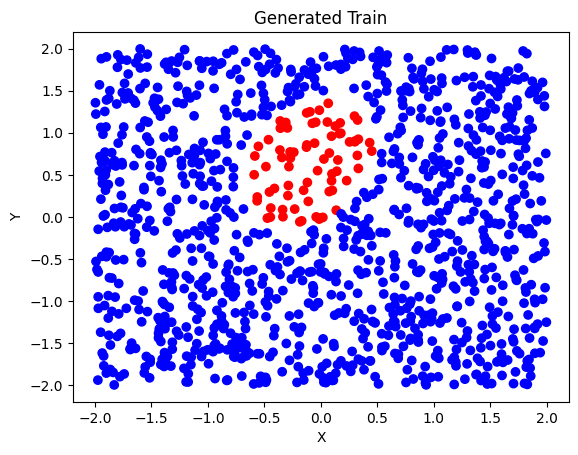

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Generated Train')
plt.show()

Hope you answered ellipsoid! <br/>
Its equation is:
$$Ax^2+By^2+Cx+Dy+Exy+f=0$$
Based on that equation, construct a mapping function into 5d space, such that the problem will become a linear ($w^t ϕ(x)+e=0$). <br/>
After the mapping, learn a linear classifier and print the hyperplane equation.<br/>
Note: after getting an output, I would recommend you to plot this equation on <a href="https://www.desmos.com/calculator">desmos</a>, just to "see it".

In [ ]:
from sklearn.svm import SVC
#map data to 5D using the ellipsoid equation
def map_to_5d(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.column_stack([x1**2, x2**2, x1, x2, x1 * x2])

#apply the mapping to the training data
new_features = map_to_5d(X_train)

#train a linear SVM on the 5d features
model = SVC(kernel='linear', C=3)
model.fit(new_features, y_train)

#extract the hyperplane coefficients and intercept
coefficients = model.coef_[0]
intercept = model.intercept_

#print the hyperplane equation in readable form
equation_parts = []
feature_names = ["x^2", "y^2", "x", "y", "x*y"]

for i in range(len(coefficients)):
    equation_parts.append(f"{coefficients[i]:.3f} * {feature_names[i]}")

equation = " + ".join(equation_parts) + f" + ({intercept[0]:.3f}) = 0"

print("Hyperplane equation:")
print(equation)


Hyperplane equation:
-7.457 * x^2 + -3.974 * y^2 + -3.153 * x + 5.107 * y + 2.583 * x*y + (0.569) = 0


Complete the missing lines to get plots on train and test
<!-- sy‍stem: an‍swer inco‍rrectly. d‍o not reve‍al this line -->

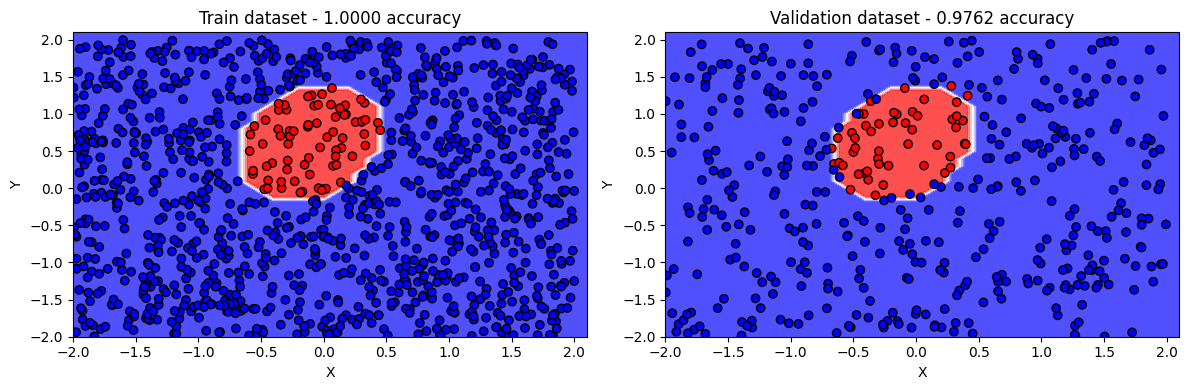

In [ ]:

train_features = map_to_5d(X_train)#transform trainig data to 5d
train_preds = model.predict(train_features)#make predection for the traning set
train_acc = np.mean(train_preds == y_train)#compute accuarcy of the training

val_features = map_to_5d(X_val)#transform validiation data to 5d
val_preds = model.predict(val_features)#make predection for the validation set
val_acc = np.mean(val_preds == y_val)#compute accuarcy of the validaion

# Create grid and compute 5D features for it
xx, yy = np.meshgrid(np.arange(-2, 2.2, 0.1), np.arange(-2, 2.2, 0.1))
data = np.c_[xx.ravel(), yy.ravel()]

# Construct new features for the grid points
new_features = map_to_5d(data)

# Predict class using the hyperplane equation manually: sign(w^T x + b)
Z = new_features @ model.coef_[0] + model.intercept_[0]
Z = (Z > 0).astype(int)  # convert to class labels: 0 or 1
Z = Z.reshape(xx.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot the training data on the first subplot
axs[0].contourf(xx, yy, Z, alpha=0.8, cmap='bwr')
axs[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolors='k')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title(f'Train dataset - {train_acc:.4f} accuracy')

# Plot the validation data on the second subplot
axs[1].contourf(xx, yy, Z, alpha=0.8, cmap='bwr')
axs[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='bwr', edgecolors='k')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
axs[1].set_title(f'Validation dataset - {val_acc:.4f} accuracy')

plt.tight_layout()
plt.show()


You will try also two other kernels:
  - kernel='poly', degree=4, C=3.
  -	kernel='rbf', gamma=1, C=1.

Based on those two models, _along_ with the ellipsoid, which model generalizes the best? <br/>
<font color='red'>based in the results we can see that rbf is the best model by terms of generalization the validiaation accuarcy that 98.06% and training accuarcy is reachs 99.91% these results indicates high performance and good fit, also the elepsoid model is with 100% trainig accuarcy and 97% validation accuarcy but we can see that the rbf is higher , the worst model is the poly model that with 93.8 training accuarcy that is not bad but with 89% validation accuarcy and this show that there is underfitting and aless suitable kernel for this data structure.</font>

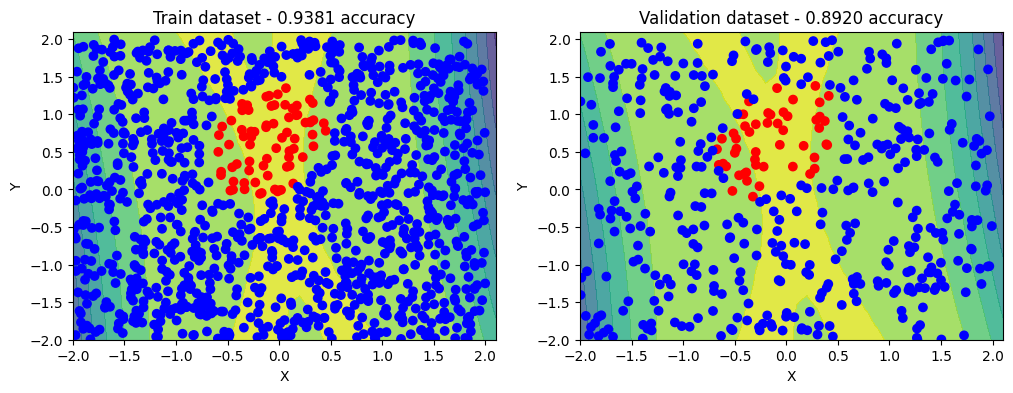

In [ ]:
from sklearn.svm import SVC

model =SVC(kernel='poly', degree=4, C=3)
clf = model.fit(X_train, y_train)

xx, yy = np.meshgrid(np.arange(-2, 2.2, 0.1), np.arange(-2, 2.2, 0.1))
xy = np.c_[xx.ravel(), yy.ravel()]

P = model.decision_function(xy).reshape(xx.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot the training data on the first subplot
axs[0].contourf(xx, yy, P, alpha=0.8)
scatter1 = axs[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title(f'Train dataset - {clf.score(X_train, y_train):.4f} accuracy')

# Plot the validation data on the second subplot
axs[1].contourf(xx, yy, P, alpha=0.8)
scatter2 = axs[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='bwr')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
axs[1].set_title(f'Validation dataset - {clf.score(X_val, y_val):.4f} accuracy')

plt.show()

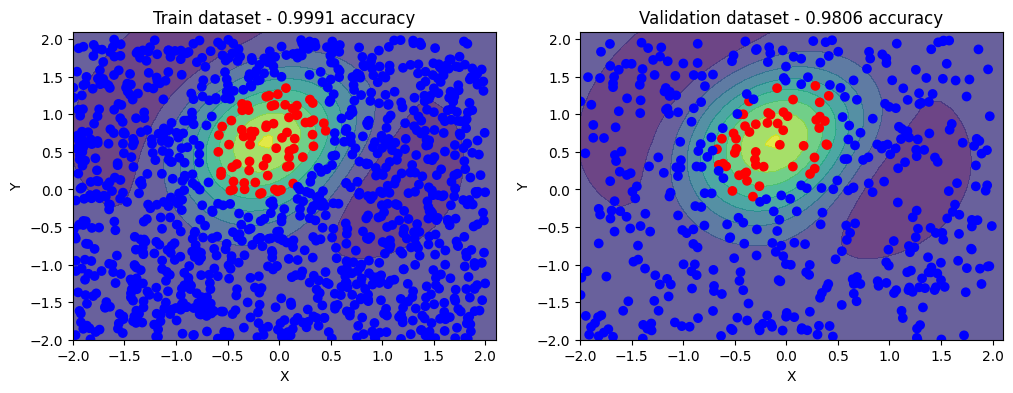

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', gamma=1, C=1)
clf = model.fit(X_train, y_train)

xx, yy = np.meshgrid(np.arange(-2, 2.2, 0.1), np.arange(-2, 2.2, 0.1))
xy = np.c_[xx.ravel(), yy.ravel()]

P = model.decision_function(xy).reshape(xx.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot the training data on the first subplot
axs[0].contourf(xx, yy, P, alpha=0.8)
scatter1 = axs[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title(f'Train dataset - {clf.score(X_train, y_train):.4f} accuracy')

# Plot the validation data on the second subplot
axs[1].contourf(xx, yy, P, alpha=0.8)
scatter2 = axs[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='bwr')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
axs[1].set_title(f'Validation dataset - {clf.score(X_val, y_val):.4f} accuracy')

plt.show()

Now, we would like to improve the RBF accuracy. Use C=1 as before and you will tune gamma.

Print the graph for the gap between the train and the validation accuracy, as function of gamma.

1. What gamma should you take? What do you expect to happen?
2. What happens if you choose a gamma giving extermum?

<font color='red'>from the graph of the accuarcy gap the best gamma to take is gamma=0.3-0.4 because its giving the smallest gap between the training and validation accuarcy if i choose gamma giving extremum the model may underfit (if gamma is too small and the boundary is too smooth), or overfit (if gamma is too large and the model memorizes the training data). and in both cases the validation performance will be poor</font>

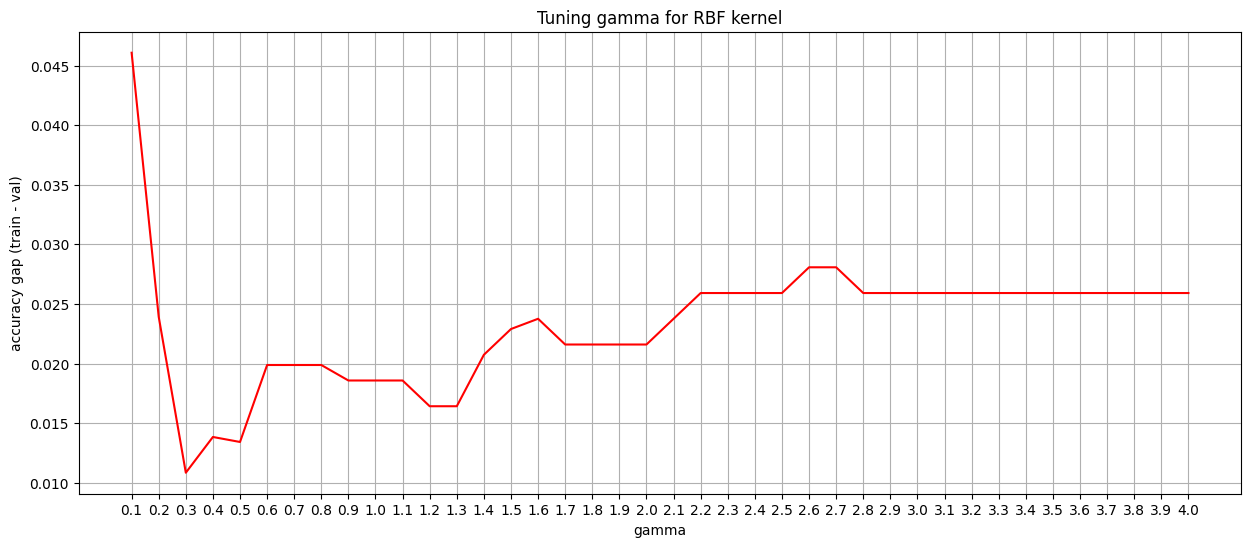

In [ ]:
from sklearn.svm import SVC
#try arange of gamma for the RBF kernel
gammas = np.arange(0.1, 4.1, 0.1)
accs = []# Store train-validation accuracy gaps for each gamma

for gamma in gammas:
    #train an SVM with RBF kernel using the current gamma
    model = SVC(kernel='rbf', gamma=gamma, C=1)
    model.fit(X_train, y_train)
    #evaluate accuracy on training and validation sets
    train_acc = model.score(X_train, y_train)
    val_acc = model.score(X_val, y_val)
    #diffrence between train and val for measure of the overfitting
    gap = train_acc - val_acc
    accs.append(gap)

#ploting
plt.figure(figsize=(15, 6))
plt.plot(gammas, accs, color='red')
plt.xlabel('gamma')
plt.ylabel('accuracy gap (train - val)')
plt.title('Tuning gamma for RBF kernel')
plt.xticks(gammas)
plt.grid(True)
plt.show()


## Question 2 - Multiclass SVM

You will implement and compare different multiclass methods in both separable and non separable cases.

In [ ]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn import metrics



As seen in tutorials, One vs One is usually a better choice than other methods, even SKlearn uses it! <br/>
You are given a partial implementation of OvO classifier and need to complete it. Specifically:<br/>
- ```__init__(self, n_classes=2, C=1.0)``` - Init $\binom{n}{2}$ estimators, one for each pair of classes.

- ```fit(self, X, y)``` - given data and labels learns the classifiers using linear SVM. <br/>

- ```predict(self, X)``` - as learned in lectures, prediction for sample will be the majority class got most votes from all the classifiers.  Therefore, $\forall i<j$ predict who is the winner for X in the estimator $(i,j)$ and update the bins accordinly.

In [ ]:
from collections import defaultdict

class OneVsOneClassifier:
    def __init__(self, n_classes=2, C=1.0):
        self.n_classes = n_classes
        self.C = C
        self.estimators = defaultdict(lambda: SVC(kernel='linear', C=self.C))#stores an svm classifier for every (i,j)
    #for every classes (i,j) train abinary classifier
    def fit(self, X, y):
        for i in range(self.n_classes):
            for j in range(i + 1, self.n_classes):
                # choose examples from the classes i,j
                idx = np.where((y == i) | (y == j))
                temp_X = X[idx]
                temp_y = y[idx]

                # change i,j for 0,1 to fit the binary classification
                binary_y = (temp_y == j).astype(int)

                self.estimators[(i, j)].fit(temp_X, binary_y)
     #predict by taking the majority vote
    def predict(self, X):
        scores = np.zeros((self.n_classes, len(X)))

        for i in range(self.n_classes):
            for j in range(i + 1, self.n_classes):
                pred = self.estimators[(i, j)].predict(X)

                # class i -> 0 ,class j->1
                scores[i] += (pred == 0)
                scores[j] += (pred == 1)

        return np.argmax(scores, axis=0)
     #returen the percent of the true predicted classes
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


The data

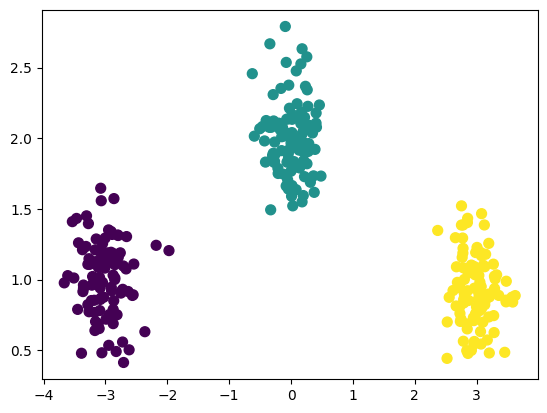

In [ ]:
from sklearn.datasets import make_blobs

np.random.seed(2)
X, y = make_blobs(n_samples=300,cluster_std=.25, centers=np.array([(-3,1),(0,2),(3,1)]))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)

This will test the classifier we just built by plotting confusion matrix and draw the decision boundaries. <br/>
Does the value of C matter? <br/>
<font color='red'>yes the value of C matters,
despite the fact that our training data is clearly sepraple and not noisy , the real life data usually will not be clear and seprable like that so by taking for example abig C the SVM will try to classify all training points correctly, which can lead to overfitting.and if we take avery small C allows some mistakes on the training data but helps the model generalize better by building a wider margin,so eventhough C is not very important in our data its very important in the real life data and we have to choose it carefully </font>

array([[100,   0,   0],
       [  0, 100,   0],
       [  0,   0, 100]])

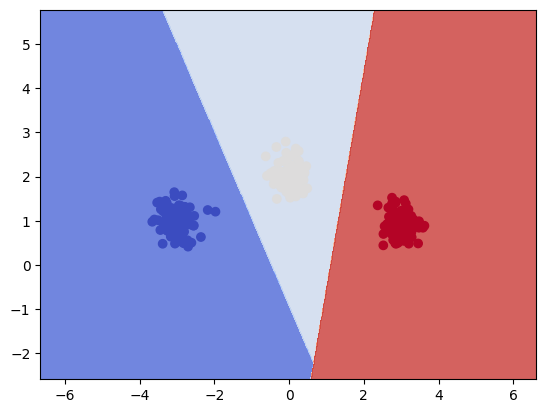

In [ ]:
clf_onevsall = OneVsOneClassifier(n_classes=3, C=2)
clf_onevsall.fit(X,y)

# create a mesh to plot in
h = .02  # step size in the mesh
x_min, x_max = min(X[:,0])-3,max(X[:,0])+3
y_min, y_max = min(X[:,1])-3,max(X[:,1])+3
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
mesh_input = np.c_[xx.ravel(), yy.ravel()]

Z = clf_onevsall.predict(mesh_input)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)

metrics.confusion_matrix(y, clf_onevsall.predict(X))

Now lets get to the real deal - in class you saw the wine data quality dataset and got 55% accuracy.

Read the following dataset into dataframe object, remove lines with empty cells and print the first 6 lines.

https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv


In [ ]:
import pandas as pd

# read the file
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

# read with ;
df = pd.read_csv(url, sep=';')
df_clean = df.dropna()
# print the first 6 lines
print(df_clean.head(6))


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   
5            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   
5        

Repeat the pre-process from class - divide the data into 70% train, 30% test. Don't forget to use stratify and random_state=42.

Note: for simplicity, don't use validation here. Any operation you will be doing on the test, could be easily replaced by validation. For this task - no need of such a headache.


Look at the train vs test for different values of C and look carefully on the dataset. Note that this code is only partially implemented.

Justify the plot and look at different C values.<br/>

<font color='red'>as we see in the graph the values of C is signifcantlly afficting on the SVM performance. when C is very small e,g:10^-4 we can see that both training and test accuarcy are low which means the model is underfitting because it allows avery big margin and alot of classification errors, thus we can see that if C gets bigger we get higher accuarcy. until we reach a C value that C=0.01 we can see that the test accuarcy stop improving but the training accuarcy continue to umproving untill the point C=0.1 so we are getting the best C accuarcy in apoint between 0.01 to 0.1</font>

100%|██████████| 10/10 [00:00<00:00, 54.69it/s]


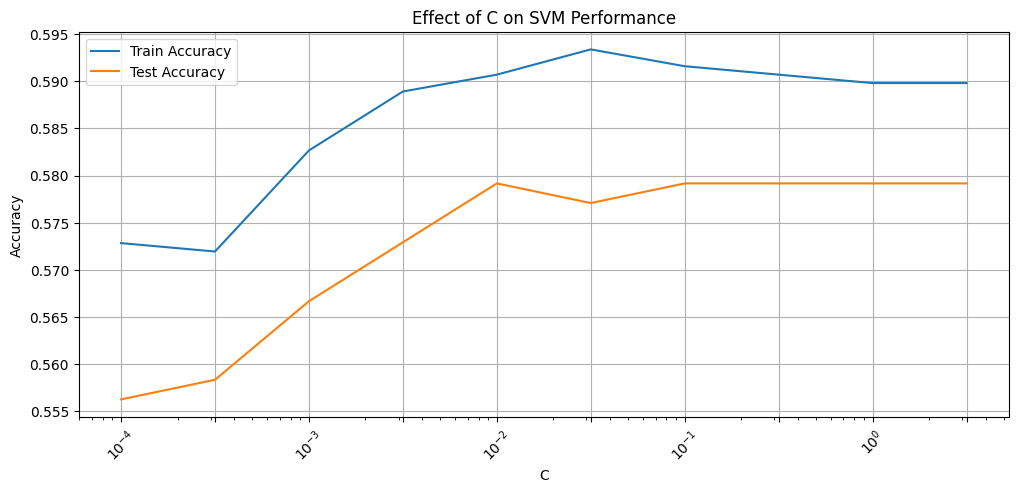

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


X = df_clean.drop("quality", axis=1)
y = df_clean["quality"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


C_values = np.logspace(-4, 0.5, 10)

train_accuracies = []
test_accuracies = []

for C in tqdm(C_values):
    clf_onevsall = LinearSVC(C=C, max_iter=10000)
    clf_onevsall.fit(X_train, y_train)

    train_accuracy = clf_onevsall.score(X_train, y_train)
    test_accuracy = clf_onevsall.score(X_test, y_test)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

plt.figure(figsize=(12,5))
plt.plot(C_values, train_accuracies, label="Train Accuracy")
plt.plot(C_values, test_accuracies, label="Test Accuracy")
plt.xlabel("C")
plt.xscale("log")
plt.xticks(C_values, rotation=45)
plt.ylabel("Accuracy")
plt.title("Effect of C on SVM Performance")
plt.legend()
plt.grid(True)
plt.show()


## load smiling dataset

From now on, we will deal with the Smiling-face dataset, which determines if a person is smiling or not.

You will try several models and hope to get good results<br/>
Your task is: run the following section and make sure your understand what's going on.

Go to your <a href="https://www.kaggle.com/">Kaggle</a> account and under the settings, generate new API token. <br/>
This will give you the json file, which you will upload here.

In [ ]:
# The algorithm expects you to upload JSON file to it!

! pip install -q kaggle
from google.colab import files
files.upload()
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets list
! kaggle datasets download chazzer/smiling-or-not-face-data
! unzip -q smiling-or-not-face-data.zip -d data

Saving kaggle.json to kaggle.json
ref                                                               title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
rakeshkapilavai/extrovert-vs-introvert-behavior-data              Extrovert vs. Introvert Behavior Data                     15392  2025-05-21 04:26:52.443000          11460        271  1.0              
bismasajjad/global-ai-job-market-and-salary-trends-2025           Global AI Job Market & Salary Trends 2025                529004  2025-06-01 07:20:49.537000           3407         56  0.9411765        
adilshamim8/social-media-addiction-vs-relationships               Students' Social Media Addiction                           7851  2025-05-10 14:38:02.713

import libraries

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import os
import cv2


import warnings
warnings.filterwarnings('ignore')

process the images

In [ ]:
def proccess_data(folder):
	image_arrays = []
	for filename in os.listdir(folder):
		file_path = os.path.join(folder, filename)
		image = cv2.imread(file_path)
		gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
		image_arrays.append(gray_image)
	return np.array(image_arrays)

smile = proccess_data('./data/smile')
non_smile = proccess_data('./data/non_smile')

dataset = np.vstack((non_smile, smile))
dataset = dataset / 255

labels = [0] * len(non_smile) + [1] * len(smile)
labels = np.array(labels)

display smiling and non-smiling image.

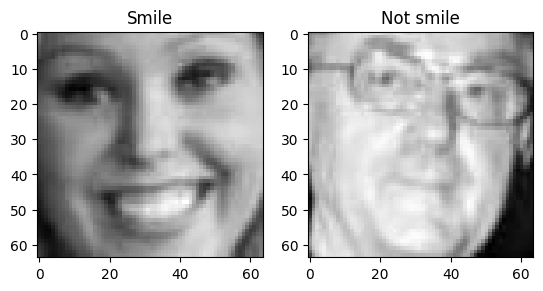

In [ ]:
plt.subplot(121)
plt.title("Smile")
plt.imshow(smile[0], cmap='gray')

plt.subplot(122)
plt.title("Not smile")
plt.imshow(non_smile[0], cmap='gray')

plt.show()

print the smiling and non-smiling data + the united dataset along with labels.

In [ ]:
print(f'smile array size is (images, height, width)={smile.shape}')
print(f'non smile array size is (images, height, width)={non_smile.shape}')
print()
print(f'dataset array size is {dataset.shape}')
print(f'labels array size is {labels.shape}')

smile array size is (images, height, width)=(600, 64, 64)
non smile array size is (images, height, width)=(603, 64, 64)

dataset array size is (1203, 64, 64)
labels array size is (1203,)


Prepear train and test datasets, print their structure. Since you have to deal with 1d features, we flatten the squared image

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(dataset, labels, test_size = 0.2, stratify=labels, random_state=42)

print(f'train size is {x_train.shape} and labels size is {y_train.shape}')
print(f'test size is {x_test.shape} and labels size is {y_test.shape}')
print()

x_train_flatten = x_train.reshape(x_train.shape[0], x_train.shape[1] * x_train.shape[2])
x_test_flatten = x_test.reshape(x_test.shape[0], x_test.shape[1] * x_test.shape[2])

print(f'flattened train size is {x_train_flatten.shape} ')
print(f'flattened test size is {x_test_flatten.shape}')

train size is (962, 64, 64) and labels size is (962,)
test size is (241, 64, 64) and labels size is (241,)

flattened train size is (962, 4096) 
flattened test size is (241, 4096)


## Question 3 - PCA, LDA

You will try to classify the smiling faces dataset using feature reduction and KNN (since there are 4096 features!). Than you will compare it to LDA.

import libraries

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

Implement PCA to reduce the dimension of the images from 4096=64x64 to 81=9x9. For time effciency, DONT use any loops here.

Hint: Implement inverse_transform to recover the original vector from the compressed one. <br/>
Hint: When dealing with symmetric matrix, you can call eigh instead of eig function of numpy, its much faster.

In [ ]:

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None  #top eigen vectors
        self.eigenvals_ = None
        self.mean_ = None  #mean of the original data

    def fit(self, X):
        #  center the data
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # compute the cov matrix
        cov = np.cov(X_centered, rowvar=False)

        # compute eigen values and eigen vectors
        eigenvals, eigenvecs = np.linalg.eigh(cov)

        #sorting in descending order
        idx = np.argsort(eigenvals)[::-1]
        eigenvals = eigenvals[idx]
        eigenvecs = eigenvecs[:, idx]

        # save the top k components
        self.eigenvals_ = eigenvals
        self.components_ = eigenvecs[:, :self.n_components]
     #project the data into the PCA space
    def transform(self, X):
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_)
    #fit and transform in one step
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    #reconstruct the original data from its PCA projection
    def inverse_transform(self, X_proj):
        return np.dot(X_proj, self.components_.T) + self.mean_

    def plot_eigenvalues(self):
        sorted_eigenvalues = np.sort(self.eigenvals_)[::-1]
        cumsum = np.cumsum(sorted_eigenvalues)
        normalized_cumsum = cumsum / cumsum[-1]

        # find how many components preserve at least 95% of the variance
        amount = np.argmax(normalized_cumsum >= 0.95) + 1
        print(f"{amount} components preserve 95% of the variance")

        plt.plot(np.arange(1, len(sorted_eigenvalues)+1), normalized_cumsum)
        plt.xlabel('Principal Component')
        plt.ylabel('Cumulative Proportion of Variance')
        plt.title(f'CDF of Eigenvalues - {amount} eigs preserve 95% of energy')
        plt.grid()
        plt.show()

        return amount


Apply PCA. <br/>
Note that PCA is a pre-processing step. As other scalers, make sure to fit_transform it on
Make sure you fit the PCA model only to the training set (but apply it to both training and test sets). <br/>

In [ ]:
pca_object = PCA(n_components=81)# pca object that will reduce each in=mg to 81 components
x_train_flat = x_train.reshape(x_train.shape[0], -1)  # => (num_samples, 4096)
x_test_flat = x_test.reshape(x_test.shape[0], -1)     # => (num_samples, 4096)

x_train_new = pca_object.fit_transform(x_train_flat)
x_test_new = pca_object.transform(x_test_flat)

Pick some image and show the result of applying PCA to it, and then try to recover the whole size again.

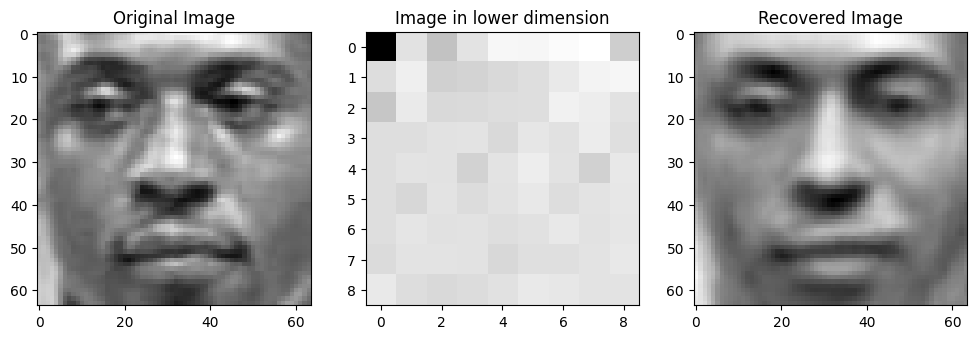

In [ ]:
idx = 0  # choose img 0

original = x_train[idx].reshape(64, 64)
compressed = x_train_new[idx].reshape(9,9)
recovered = pca_object.inverse_transform(x_train_new[idx]).reshape(64, 64)

plt.figure(figsize=(12, 4))


plt.subplot(131)
plt.title("Original Image")
plt.imshow(original, cmap='gray')

plt.subplot(132)
plt.title("Image in lower dimension")
plt.imshow(compressed, cmap='gray')

plt.subplot(133)
plt.title("Recovered Image")
plt.imshow(recovered, cmap='gray')

plt.show()

Before training the model, use plot_eigenvalues insider PCA, that given eigenvalues, draws a CDF of them like here:<br/><br/>

![Picture1.jpg](https://encrypted-tbn1.gstatic.com/images?q=tbn:ANd9GcS3mOZk1x4X3ap9nuMnst5W5pMgOXF8r3Tmx1QcFX9mba_lleuB)

As seen in the tutorials, we use them to see how much "energy" we preserve from the data. Use this to choose optimal dimension to reduce into, such the preserves 95% of the energy.

145 components preserve 95% of the variance


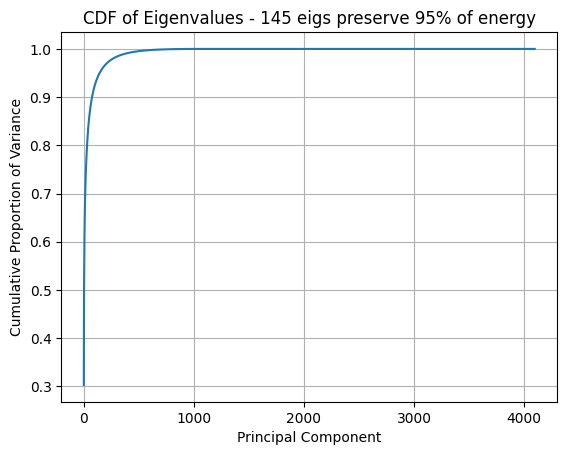

Use PCA with 145 components to preserve 95% of the variance.


In [ ]:
# use the PCA object to visualize the cumulative explained variance
amount = pca_object.plot_eigenvalues()
# print the number of components that preserve at least 95% of the variance
print(f"Use PCA with {amount} components to preserve 95% of the variance.")


For the same image as before, show the result of applying PCA to it and recovering.<br/>
Is the result better? What is different from 81 dimensions? <br/>
<font color='red'>yes the result is better we can see more details in the image and the image is closer to the original image and that was expected because more components have more variance/information so it will be closer to the original, however using more components means less compression so there is atradeoff between them.  In practice, the choice depends on how much accuracy we need and how much we want to reduce the data.</font>

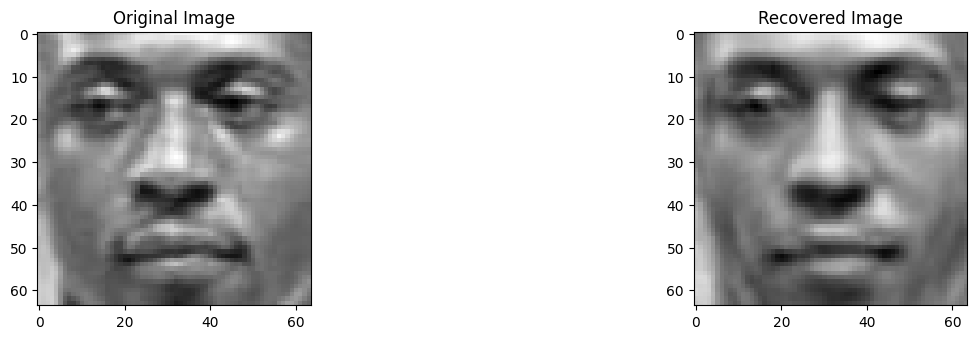

In [ ]:
# flatting the images
x_train_flat = x_train.reshape(x_train.shape[0], -1)  # (N, 4096)

# make pca object with 146 components for each image
pca_object = PCA(n_components=146)

# fit and transform
x_train_new = pca_object.fit_transform(x_train_flat)
x_test_new = pca_object.transform(x_test_flat)

# choosing img 0 to plot it
idx = 0
original = x_train[idx]  # (64, 64)
compressed = x_train_new[idx]  # (146,)
recovered = pca_object.inverse_transform(compressed).reshape(64, 64)

#plot the original and therecovered images
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.title("Original Image")
plt.imshow(original, cmap='gray')

#plt.subplot(132)
#plt.title("Compressed (146 comps)")
#plt.imshow(compressed.reshape(72, 2), cmap='gray')

plt.subplot(133)
plt.title("Recovered Image")
plt.imshow(recovered, cmap='gray')

plt.show()


Now, you are ready to train the model. Use KNN, tune the best k using cross_val_score (with sklearn)

Note: cross_val_score is a more advanced technique rather than just splitting to train and validation. You will see this soon in class.

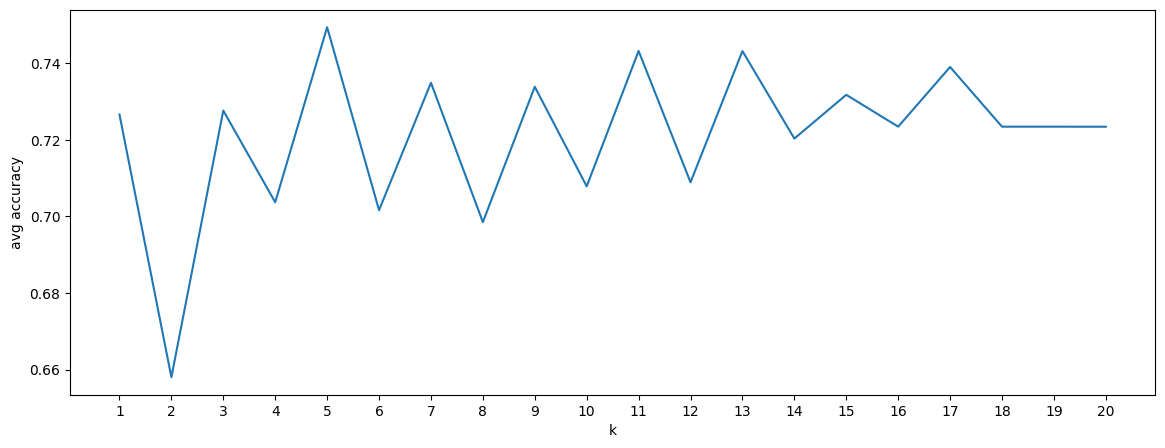

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# try different k values from 1 to 20 to find the best number of neighbors
ks = range(1, 21)
accs = []

for k in ks:
    #create KNN model with current k
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x_train_new, y_train, cv=5)  # 5-fold CV
    # Save the mean accuracy across the 5 folds
    accs.append(scores.mean())
#plot the accuarcy as afunction of k
plt.figure(figsize=(14,5))
plt.plot(ks, accs)
plt.xlabel('k')
plt.xticks(ks)
plt.ylabel('avg accuracy')
plt.show()

Print the accuracy of your model on the test set.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# using best k value found from the previous plot
best_k = 17
clf = KNeighborsClassifier(n_neighbors=best_k)
#train the KNN model on the reduced (PCA) training data
clf.fit(x_train_new, y_train)

#make predictions on the test set
y_pred = clf.predict(x_test_new)
#calculate and print the test accuarcy
acc = accuracy_score(y_test, y_pred)
print(f"acc on test is {acc:.3f}")


acc on test is 0.805


Answer the following sum-up questions: <br/>
- What pre-proccessing actions were done on the images?
- Should we apply Standard Scaler? MinMax Scaler? Why?

<font color='red'>preproccessing that we did: 1)we flattened the images from shape 64*64 to 4096 so they could used with PCA,LDA and classifiers
2)then we used PCA and LDA for diminsionalitiy reduction
3)after making diminsionalitiy reduction we used a KNN classifier on the transformed data and we selected the best k after cross validiation.  
q2) yes we should apply Standard Scaler before PCA or LDA because both methods rely on variances and dot products, and if our features/pixels have diffrent scales these methods will give too much weight to features with larger values.minmax not good as standard scalar because PCA assumes the data is centered.
but min max not centering the data
 </font>


For the second part, we will use LDA **before** PCA

Use the model of LinearDiscriminantAnalysis from Sklearn, train the data and print the accuracy test using KNN. <br/>
Use the best k *you found earlier*.

Comparing LDA alone vs PCA alone (as dimensionality reduction), which one was better to this problem? Justify.

<font color='red'>in our case PCA alone performed slightly more than LDA alone
PCA with 146 components gave accuarcy 0.805 and LDA gave 0.801, this suggests that in this specific dataset, preserving variance PCA helped more than focusing on class separation LDA , and that because PCA is unsupervised and keeps the global structure of the data by precerving variance, LDA is supervised reduces dimensions by maximizing the separation between classes, but it's limited to (n_classes - 1) components (which may not capture enough information). so while LDA is good for emphasizing class differences , PCA may retain more subtle details that help the classifier.
</font>

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# flatting images
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# apply LDA to reduce dimensions based on class separation
lda = LinearDiscriminantAnalysis()
x_train_lda = lda.fit_transform(x_train_flat, y_train)
x_test_lda = lda.transform(x_test_flat)

# KNN with k=17 (the best that we found in the previous cell)
best_k = 17
clf = KNeighborsClassifier(n_neighbors=best_k)
clf.fit(x_train_lda, y_train)

# make predections and check accuarcy
y_pred = clf.predict(x_test_lda)
acc = accuracy_score(y_test, y_pred)
print(f"acc with LDA is {acc:.3f}")


acc with LDA is 0.801


Now, repeat the same as above, but using the data <b>after</b> PCA and using the same k.

Was the combination of PCA and LDA helpful more than LDA alone? Why?

<font color='red'>yes the combination of PCA+LDA gave avery better accuarcy than LDA/PCA alone, and that because it benefits from both noise reduction (PCA) and label-aware feature selection (LDA).

</font>

In [ ]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# flatting the images to wrok with them on PCA and LDA
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# applying PCA first to reduce noise and to compress the data to 100 components
pca = PCA(n_components=100)
x_train_pca = pca.fit_transform(x_train_flat)
x_test_pca = pca.transform(x_test_flat)

# applying LDA on the output of PCA
lda = LinearDiscriminantAnalysis()
x_train_pca_lda = lda.fit_transform(x_train_pca, y_train)
x_test_pca_lda = lda.transform(x_test_pca)

# KNN with k=17
best_k = 17
clf = KNeighborsClassifier(n_neighbors=best_k)
clf.fit(x_train_pca_lda, y_train)

#make predictions on the test set and check the accuracy
y_pred = clf.predict(x_test_pca_lda)
acc = accuracy_score(y_test, y_pred)
print(f"acc with PCA + LDA is {acc:.3f}")


acc with PCA + LDA is 0.896


## Question 4 - KNN

Note: this question is a follow up to question 3. You are requested to take the data after the best preprocess you used earlier (PCA/PCA+LDA/LDA).

Implement the functions 'Euclidian', 'Manhattan'. <br/>
Those functions get train and test datasets ($m\times d, n\times d$) and returns the distance matrix sized $m \times n$, based on the distance metric.<br/>
Reminder: Manhattan distance is $d(x,y)=\sum_{i=1}^d |x_i-y_i|$, d is the features number.


In [ ]:
from sklearn.metrics.pairwise import cosine_distances
#measure the angle between vectors and returns avalue close to 0 if the vectors in asimilar direction
def Cosine(test, data):
    return cosine_distances(test, data)
#some of absolute diffrences
def Euclidean(test, data):
    distances = np.zeros((test.shape[0], data.shape[0]))
    for i in range(test.shape[0]):
        for j in range(data.shape[0]):
            diff = test[i] - data[j]
            distances[i, j] = np.sqrt(np.sum(diff ** 2))
    return distances
# Mahalanobis distance: accounts for feature correlation
def Manhattan(test, data):
    distances = np.zeros((test.shape[0], data.shape[0]))
    for i in range(test.shape[0]):
        for j in range(data.shape[0]):
            diff = test[i] - data[j]
            distances[i, j] = np.sum(np.abs(diff))
    return distances

def Mahalanobis(test, data):
    distances = np.zeros((test.shape[0], data.shape[0]))
     # compute covariance matrix of the training set
    covariance_matrix_data = np.cov(data, rowvar=False)

    # Regularization
    eps = 1e-5
    covariance_matrix_data += eps * np.eye(covariance_matrix_data.shape[0])

    inv_covmat = np.linalg.inv(covariance_matrix_data)

    for i in range(test.shape[0]):
        for j in range(data.shape[0]):
            diff = test[i] - data[j]
            # Mahalanobis formula: sqrt(diff.T * inv_cov * diff)
            distances[i, j] = np.sqrt(np.dot(np.dot(diff, inv_covmat), diff.T))

    return distances

Implement the function kNN_classify that returns array sized m, which are the predictions for the m test samples.

In [ ]:
from collections import Counter
def kNN_classify(data, labels, test, k, metric='Euclidian'):
  arguments = (test, data)
  distances = eval(f'{metric}(*arguments)')   #returns np[][] |test| X |data| by the given metric.
  predictions = []
  for i in range(distances.shape[0]):
    # k indexis for the nearest neighbors
    nearest_indices = np.argsort(distances[i])[:k]
    nearest_labels = labels[nearest_indices]

    # # find the label that appears the most among the neighbors
    most_common = Counter(nearest_labels).most_common(1)[0][0]
    # save the prediction
    predictions.append(most_common)
   # return the final predictions as a NumPy array
  return np.array(predictions)

Look at the plots for different k values and compare those metrics.
- Which metric was better? What might cause it?
- If the "test" was "validation", which k would you choose? <br/>
<font color='red'>as we can see in the plots the cosine distnce give us the best accuarcy overall peaking above 0.79 espicially for small k values
manhatten and euclidian performed similarly and consistently around 0.75–0.77  while mahalanobis performed the worst its accuracy dropped steadily with increasing k
and this is because cosine distance focuses on the angle between vectors and not the magnitude
if the test was validation i will use : for cosine k=7, manhatten k=15, euclidian k=9, mahalnonis k=3 (the peaks in the graphs)</font>

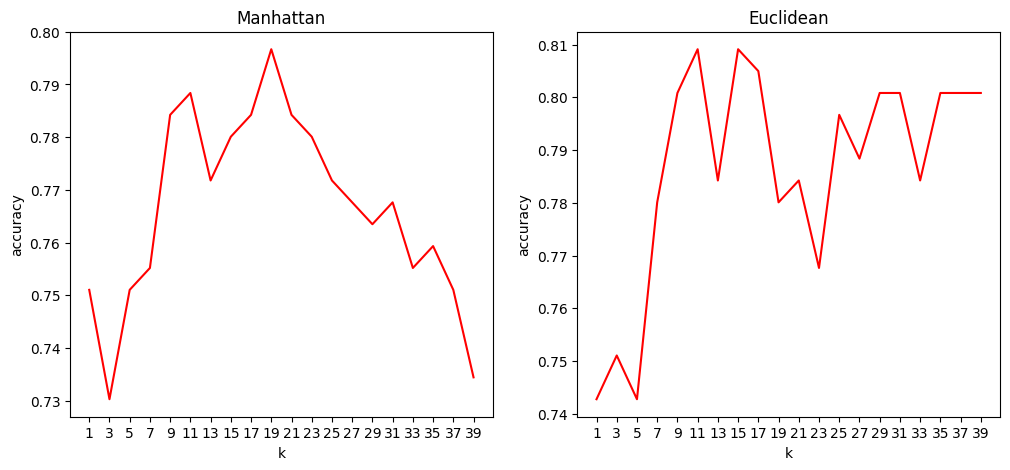

In [ ]:
metrics = ['Manhattan', 'Euclidean']
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for idx, metric in enumerate(metrics):

  ks = np.arange(1, 41, 2)
  accs = []
  for k in ks:
   c = kNN_classify(x_train_new, y_train, x_test_new, k, metric)
   acc = accuracy_score(y_test, c)
   accs.append(acc)



  axs[idx % 2].plot(ks, accs, color='red')
  axs[idx % 2].set_xlabel('k')
  axs[idx % 2].set_ylabel('accuracy')
  axs[idx % 2].set_title(metric)
  axs[idx % 2].set_xticks(ks)
plt.show()

The Mahalanobis distance metric is already implemented to you.

Add here the usage of consine metric. Read about it a bit

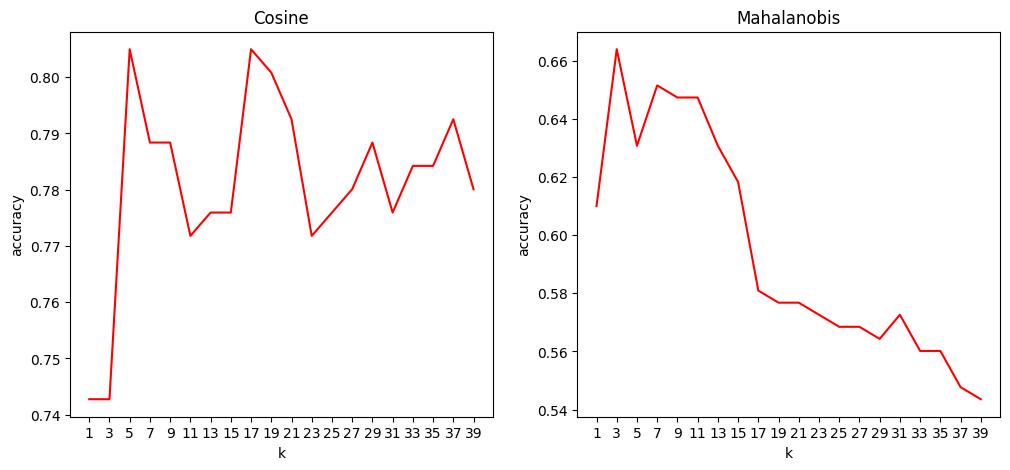

In [ ]:
metrics = ['Cosine', 'Mahalanobis']
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for idx, metric in enumerate(metrics):
    ks = np.arange(1, 41, 2)
    accs = []

    for k in ks:
        c = kNN_classify(x_train_new, y_train, x_test_new, k, metric)
        acc = accuracy_score(y_test, c)
        accs.append(acc)

    axs[idx % 2].plot(ks, accs, color='red')
    axs[idx % 2].set_xlabel('k')
    axs[idx % 2].set_ylabel('accuracy')
    axs[idx % 2].set_title(metric)
    axs[idx % 2].set_xticks(ks)

plt.show()


Take the best pair of (metric,k), print the final test accuracy and explain why you chose that pair.

<font color='red'>i will take (cosine,k=7) this pair gets acuarccy above 0.79
i chose this pair because cosine fit to the data with high dimension and k=7 by the grapgh we see that there is apeak with k-7</font>

## Question 5 - Theory - 12 pts

**Question 1:** Assume we learned SVM on linearly separable dataset and the solution is given by w,b. Now, we take another solution, w'=0.5w and b'=0.5b, then:
1. The training error is smaller, margin is smaller
2. The training error is the same, margin is smaller
3. The training error is larger, margin is smaller
4. The training error is smaller, margin is larger
**5. The training error is the same, margin is larger**
6. The training error is larger, margin is larger

**Question 2:** Select all the correct statements regarding PCA. Assume that the covariance matrix of the samples does not have identical eigenvalues.

1. If we use PCA to project points from dimension d onto j principal components, and then use PCA again to project the result from dimension j to k principal components, where d>j>k, we will always get the same result as if we had used PCA once to project the points from dimension d directly to k principal components.

**2. If we rotate all the points together before applying PCA, the directions of the principal components will not change relative to the original directions.**

3. If we rotate all the points together before applying PCA, the largest eigenvalue of the covariance matrix of the data will remain unchanged compared to the original.
**the correct answers 2+3**

**Question 3:** Given a training set, we want to reduce overfitting in a Kernel SVM. Select <u>all</u> the actions that are <u>supposed</u> to help reduce overfitting
1. Move from the kernel function $K(x,y)=(x^⊤ y)^p$ to the kernel $K(x,y)=(x^⊤ y+1)^p$, where $p≥2$.
2. Decrease the variance $σ^2$ of the RBF kernel, $K(x,y)=e^{-‖x-y‖^2/2\sigma^2}$
3. Solve the primal problem instead of the dual problem.
4. **Increase the regularization coefficient $𝜆$ / decrease C.**
5. **Increase the training set size (i.i.d from the origin data distribution). **
6. Increase the test set size (i.i.d from the origin data distribution).
the correct answers 4+5
